# Tutorial: Exploring the Generalized Uhlenbeck-Ford (UF) Model

This notebook provides a comprehensive hands-on guide to the **Uhlenbeck-Ford (UF) model**, a cornerstone reference system for liquid-phase free energy calculations. We will explore its mathematical derivation, its unique dimensionless scaling, and how its structural and thermodynamic properties change as we tune its steepness parameter $p$.

---

## 1. Potential Definition

The UF model is defined by a purely repulsive, ultrasoft pair potential that diverges only logarithmically at the origin.

### 1.1 Generalized UF Potential
The generalized UF potential is given by:

$$V(r) = -k_B T \ln \left[ 1 - \exp\left( -\left( \frac{r}{\sigma} \right)^{2p} \right) \right]$$

where:
- $p$ is the steepness parameter ($p=1$ is the standard Gaussian model).
- $\sigma$ is the length scale (characteristic diameter).
- $k_B T$ sets the energy scale, making the potential temperature-dependent.

## 2. Statistical Mechanics and Dimensionless Scaling

The primary advantage of the UF model is that its structural and thermodynamic properties can be mapped to a single dimensionless parameter $x$.

### 2.1 The Mayer f-function
The Mayer f-function $f(r) = e^{-V(r)/k_B T} - 1$ characterizes the inter-particle interactions. For the UF model, substituting $V(r)$ into this definition yields:

$$f_{UF}(r) = \left( 1 - \exp\left( -\left(\frac{r}{\sigma}\right)^{2p} \right) \right) - 1 = -\exp\left( -\left(\frac{r}{\sigma}\right)^{2p} \right)$$

Note that for the standard case ($p=1$), $f_{UF}(r)$ takes a perfect Gaussian form. This mathematical elegance is why the UF model is so useful for analytic derivations.

### 2.2 Second Virial Coefficient ($B_2$)
The second virial coefficient $B_2$ represents the first-order correction to ideal gas behavior due to pair interactions:

$$B_2(p) = -\frac{1}{2} \int f(r) d^3r = \frac{1}{2} \int_0^\infty \exp\left( -\left(\frac{r}{\sigma}\right)^{2p} \right) 4\pi r^2 dr$$

Solving this integral yields the general form:
$$B_2(p) = \frac{\pi \sigma^3}{p} \Gamma\left( \frac{3}{2p} \right)$$

where $\Gamma(n)$ is the Euler Gamma function defined as:

$$\Gamma(n) = \int_0^\infty t^{n-1} e^{-t} dt$$

For $p=1$, this simplifies to the well-known 3D Gaussian volume: $B_2(1) = \frac{1}{2} (\pi \sigma^2)^{1.5}$.

### 2.3 Dimensionless Density ($x$) and Universality
The thermodynamic state of the UF fluid is uniquely determined by the dimensionless density $x$:
$$x = \rho B_2(p)$$

The compressibility factor $Z = \frac{P}{\rho k_B T}$ is traditionally derived from the **Virial equation of state**:

$$Z = 1 - \frac{\rho}{3 k_B T} \int_0^\infty g(r) \left( r \frac{dV}{dr} \right) 4\pi r^2 dr$$

#### Mathematical Proof of Temperature Independence

Let's define a **dimensionless potential** $\phi(r/\sigma, p)$ such that the actual potential $V(r, T)$ is scaled by temperature:
$$V(r) = k_B T \cdot \phi(r/\sigma, p) \quad \text{with} \quad \phi(u, p) = -\ln(1 - e^{-u^{2p}})$$

Differentiating both sides with respect to $r$ gives:
$$\frac{dV}{dr} = k_B T \frac{d\phi}{dr}$$

Substituting this into the Virial equation:
$$Z = 1 - \frac{\rho}{3 k_B T} \int_0^\infty g(r) \left( r \cdot {k_B T} \frac{d\phi}{dr} \right) 4\pi r^2 dr$$
$$Z = 1 - \frac{\rho}{3} \int_0^\infty g(r) \left( r \frac{d\phi}{dr} \right) 4\pi r^2 dr$$

Finally, in a canonical ensemble ($N, V, T$), the configurational probability (and thus the radial distribution function $g(r)$) depends only on the ratio $V/k_B T$:
$$g(r) \propto \exp\left( -\frac{V(r)}{k_B T} \right) = \exp(-\phi(r/\sigma, p))$$

As $\phi$ is temperature-independent, **$g(r)$ is also temperature-independent**, making $Z$ a universal function of $x$ and $p$. This allows us to calculate $Z(x)$ at any temperature and use it across the entire phase diagram.

## 3. Test Objectives

In this tutorial, we will verify the following characteristics of the UF model by varying $p \in \{1, 5, 10, 25\}$:

1.  **Compressibility Factor ($Z$)**: How potential steepness affects pressure at the same dimensionless density $x$.
2.  **Radial Distribution Function (RDF)**: Observing the transition from a smooth, "soft" fluid ($p=1$) to a structured, "hard-sphere-like" fluid ($p=25$).
3.  **Diffusion (MSD)**: Analyzing how the mobility of particles decreases as the core repulsion becomes more rigid.
4.  **Excess Internal Energy ($U_{ex}$)**: Extracting the interaction energy contribution.

## 4. Environment Setup

First, we install the LAMMPS molecular dynamics package and the necessary Python libraries on the Google Colab instance.

In [ ]:
# Install LAMMPS (Ubuntu default version)
!sudo apt-get update
!sudo apt-get install -y lammps-stable || sudo apt-get install -y lammps

# Verification: Check if binary is 'lmp' or 'lmp_stable'
!lmp -h | head -n 1 || lmp_stable -h | head -n 1

# Install Python packages
!pip install numpy scipy matplotlib

## 5. Problem Definition & Helper Functions

### 5.1 Principles of UF Table Generation

To use the UF potential in LAMMPS, we must convert the analytic formula into a discrete numerical grid using `pair_style table`. The reliability of this approach depends on several numerical considerations:

1.  **Logarithmic Divergence at $r \to 0$**: The potential $V(r) \propto -\ln(1 - e^{-u})$ diverges as $u \to 0$. Simply evaluating this at $r=0$ would cause numerical errors. We use a **Taylor expansion** approach: for very small distances ($r \to 0$), $1 - e^{-u} \approx u$, so $V(r) \approx -2p \ln(r/\sigma)$. This ensures that the potential and forces remain well-defined and stable even if atoms overlap during the initial equilibration.
2.  **Grid Resolution**: We use **5000 points** sampled linearly. This high density is crucial because as $p$ increases, the potential slope becomes extremely sharp at $r \approx \sigma$. A coarse grid would lead to inaccurate force calculations and energy drift.
3.  **Temperature Scaling**: The master data for UF is dimensionless. When generating the table for a specific simulation at temperature $T$, we multiply the dimensionless potential by $k_B T$ to maintain the $T^* = 1$ condition, which is the foundation of the model's universal scaling.

We define the physical constants and functions below.

In [2]:
import numpy as np
import scipy.special as special
import matplotlib.pyplot as plt
import subprocess
import os

KB_EV = 8.617333262145e-5
EV_A3_TO_BAR = 1602176.6

def calculate_b2(p, sigma=2.5):
    gamma_val = special.gamma(3.0 / (2.0 * p))
    return (np.pi * (sigma**3) / p) * gamma_val

def generate_uf_table(p, sigma=2.5, r_max=10.0, n_points=5000):
    filename = f"uf_p{p}.table"
    rs = np.linspace(0.005, r_max, n_points)
    with open(filename, "w") as f:
        f.write(f"# UF potential p={p}\n\nUF_P{p}\nN {n_points}\n\n")
        for i, r in enumerate(rs):
            term = (r/sigma)**(2*p)
            if term < 1e-15:
                v_dim = -np.log(term)
                f_dim = (2*p/sigma) / (r/sigma)
            else:
                v_dim = -np.log(1.0 - np.exp(-term))
                f_dim = (2*p/sigma) * (r/sigma)**(2*p-1) * np.exp(-term) / (1.0 - np.exp(-term))

            # Simulation at T=1000K
            T = 1000.0
            f.write(f"{i+1} {r} {v_dim * KB_EV * T} {f_dim * KB_EV * T}\n")
    return filename

## 6. Running Robust Simulations

MD results are prone to statistical fluctuations. We address this by:
1. **Long Equilibration**: 10,000 steps to ensure the system is relaxed.
2. **Time-Averaging**: Instead of using snapshot values, we use `fix ave/time` for potential energy and pressure to obtain stable thermodynamic means.
3. **RDF/MSD Accumulation**: Sampling structural data over the entire production phase.

In [3]:
import time

ps = [1, 5, 25]
x_target = 2.0
sigma = 2.5
T = 1000.0

lmp_cmd = subprocess.getoutput("which lmp || which lmp_stable || which lmp_serial || which lmp_mpi").strip()
if not lmp_cmd:
    print("Error: LAMMPS binary not found! Please check installation section.")
else:
    print(f"Using LAMMPS binary: {lmp_cmd}")

for p in ps:
    print(f"Running Rigorous MD for p={p}...")
    b2 = calculate_b2(p, sigma)
    rho = x_target / b2
    n_atoms = 1000
    side = (n_atoms / rho)**(1/3.0)
    table_file = generate_uf_table(p, sigma)

    in_content = f"""
units metal
atom_style atomic
boundary p p p

region box block 0 {side} 0 {side} 0 {side}
create_box 1 box
create_atoms 1 random {n_atoms} 12345 box

mass 1 28.0855
pair_style table linear 5000
pair_coeff 1 1 {table_file} UF_P{p}

minimize 1.0e-4 1.0e-6 100 1000

velocity all create {T} 12345
fix 1 all nvt temp {T} {T} 0.1

thermo 2000
thermo_style custom step temp press pe
run 10000 # Long Equilibration

reset_timestep 0

# Rigorous Block Averaging over 10,000 Production Steps
variable v_pe equal pe
variable v_press equal press
fix f_ave all ave/time 10 1000 10000 v_v_pe v_v_press

compute myRDF all rdf 100
fix f_rdf all ave/time 10 1000 10000 c_myRDF[*] file rdf_p{p}.out mode vector

compute myMSD all msd
# Output MSD every 50 steps for time-series analysis
fix f_msd all ave/time 1 1 50 c_myMSD[4] file msd_p{p}.out

thermo 10000
thermo_style custom step temp press pe f_f_ave[1] f_f_ave[2]
run 10000 # Production
"""
    for f in [f"log.p{p}", f"rdf_p{p}.out", f"msd_p{p}.out"]:
        if os.path.exists(f): os.remove(f)

    with open(f"in.p{p}", "w") as f: f.write(in_content)
    !{lmp_cmd} -in in.p{p} -log log.p{p} > /dev/null

    time.sleep(1)
    !sync

    if os.path.exists(f"rdf_p{p}.out"):
        print(f"p={p} simulation finished successfully.")
    else:
        print(f"Error: Simulation for p={p} incomplete! Check log.p{p}")

Using LAMMPS binary: /usr/bin/lmp
Running Rigorous MD for p=1...
p=1 simulation finished successfully.
Running Rigorous MD for p=5...
p=5 simulation finished successfully.
Running Rigorous MD for p=25...
p=25 simulation finished successfully.


## 7. Results Analysis

### 7.1 RDF Comparison

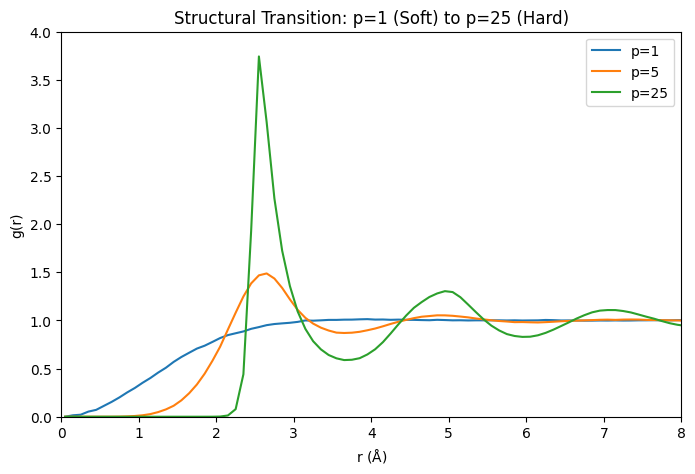

In [4]:
plt.figure(figsize=(8, 5))
for p in ps:
    data = np.loadtxt(f"rdf_p{p}.out", skiprows=4)
    plt.plot(data[:,1], data[:,2], label=f"p={p}")
plt.xlabel(r"r ($\mathrm{\AA}$)")
plt.ylabel("g(r)")
plt.title("Structural Transition: p=1 (Soft) to p=25 (Hard)")
plt.xlim(0,8)
plt.ylim(0,4)
plt.legend()
plt.show()

### Interpretation of RDF Results:
- **$p=1$ (Gaussian Core)**: The first peak is extremely broad and low. This indicates that particles can overlap significantly. There is no clear second or third shell, characteristic of an **ultrasoft, gas-like liquid**.
- **$p=25$ (Hard-Sphere-like)**: The first peak is very sharp and narrow, and the second peak is clearly visible. This represents **strong short-range order**. As $p$ increases, the potential $V(r)$ approaches a Step function (Hard Sphere). The particles are excluded from $r < \sigma$ and arrange themselves in well-defined shells around their neighbors.

### 7.2 MSD Comparison and Diffusivity Calculation (Dynamic Analysis)

The diffusion coefficient $D$ is calculated using the Einstein relation:
$$ \text{MSD}(t) = 6Dt $$
We perform a linear fit on the long-time regime (after the initial ballistic period) to find the slope, where $D = \text{slope} / 6$.

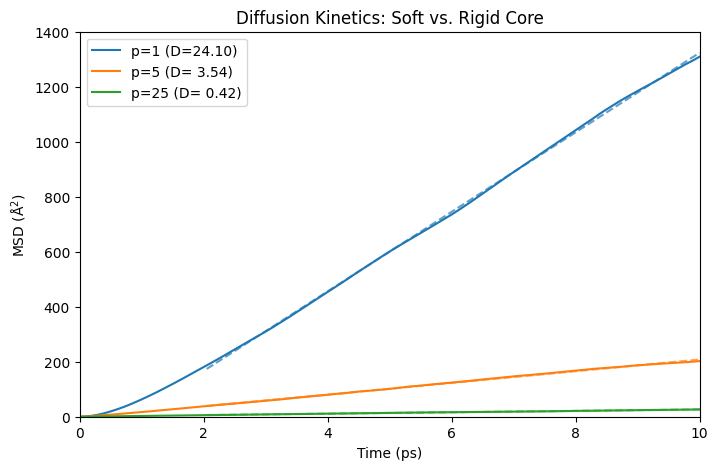


Diffusivity (D) Summary:
 p | Diffusivity [A^2/ps] | Diffusivity [cm^2/s]
 1 |              24.1045 |             2.41e-03 
 5 |               3.5421 |             3.54e-04 
25 |               0.4232 |             4.23e-05 


In [5]:
plt.figure(figsize=(8, 5))
diffusivities = {}

for p in ps:
    msd_file = f"msd_p{p}.out"
    if not os.path.exists(msd_file): continue
    try:
        data = np.loadtxt(msd_file, skiprows=2)
        if data.ndim == 1: continue

        time_ps = data[:,0] * 0.001
        msd_val = data[:,1]

        # Linear regression on the linear regime (t > 2 ps to avoid ballistic regime)
        linear_idx = np.where(time_ps > 2.0)[0]
        if len(linear_idx) > 10:
            # Perform fit: MSD = slope * t + intercept
            p_fit = np.polyfit(time_ps[linear_idx], msd_val[linear_idx], 1)
            slope, intercept = p_fit[0], p_fit[1]
            D = slope / 6.0
            diffusivities[p] = D

            # Plot MSD data
            line = plt.plot(time_ps, msd_val, label=f"p={p} (D={D:5.2f})")
            # Plot linear fit as dashed line with the same color
            plt.plot(time_ps[linear_idx], slope * time_ps[linear_idx] + intercept,
                     '--', color=line[0].get_color(), alpha=0.7)
    except Exception as e:
        print(f"Error reading {msd_file}: {e}")

plt.xlabel("Time (ps)")
plt.ylabel(r"MSD ($\mathrm{\AA}^2$)")
plt.title("Diffusion Kinetics: Soft vs. Rigid Core")
plt.xlim(0,10)
plt.ylim(0,1400)
plt.legend()
plt.show()

print("\nDiffusivity (D) Summary:")
print(f"{'p':>2} | {'Diffusivity [A^2/ps]':>20} | {'Diffusivity [cm^2/s]':>20}")
for p, D in diffusivities.items():
    print(f"{p:2d} | {D:20.4f} | {D*1E-4:20.2e} ")

### Interpretation of MSD Results:
- **Diffusion Speed**: The slope of the MSD curve is proportional to the diffusion coefficient ($D = \text{slope}/6$).
- **Observation**: Typically, the $p=1$ system shows faster diffusion at early times because the "soft" particles can easily squeeze past each other. In contrast, the $p=25$ particles act like rigid spheres; they are often "caged" by their neighbors, which slows down long-range diffusion at high densities.

### 7.3 Thermodynamic Properties (Z and $U_{ex}$)

In [6]:
import re

print(f"{'p':>2} | {'rho':>8} | {'Z':>8} | {'U_ex [eV/at]':>12}")
for p in ps:
    log_path = f"log.p{p}"
    if not os.path.exists(log_path): continue
    log = open(log_path).read()

    # Extract averaged values from the last line (step 10000)
    tail = re.findall(r"10000\s+[\s\d\.\-]+\s+([\d\.\-]+)\s+([\d\.\-]+)", log)
    if not tail: continue
    P_avg = float(tail[-1][1])
    U_avg = float(tail[-1][0]) / 1000.0
    b2 = calculate_b2(p, sigma)
    rho = x_target / b2
    z = P_avg / (rho * KB_EV * T * EV_A3_TO_BAR)
    print(f"{p:2d} | {rho:8.6f} | {z:8.4f} | {U_avg:12.6f}")

 p |      rho |        Z | U_ex [eV/at]
 1 | 0.045974 |   3.4440 |     0.181525
 5 | 0.068097 |   6.7265 |     0.216276
25 | 0.063087 |  12.3012 |     0.082997


### Interpretation of Thermodynamic Results ($Z$ and $U_{ex}$):
1.  **Compressibility Factor ($Z$)**: At a fixed dimensionless density $x=2.0$, $Z$ measures how much the pressure deviates from the ideal gas ($Z-1 \sim x=2.0$ for low $p$). As $p$ increases, the core of the potential becomes steeper and "harder". This leads to a higher resistance to compression, causing $Z$ to increase (from ~3.4 for $p=1$ up to ~12.3 for $p=25$).
2.  **Excess Energy ($U_{ex}$)**: As $p$ increases, the system behaves more like a hard-sphere model. In the hard-sphere limit, overlaps are forbidden, and the potential energy in the accessible region is zero. Thus, for high $p$, the particles avoid overlapping more efficiently, and $U_{ex}$ (potential energy per atom) decreases (approaching zero) compared to the very soft $p=1$ case.
3.  **Physical Meaning**: Tuning $p$ effectively turns the UF model into a mathematical proxy for different materials. $p=1$ represents ultrasoft colloids/polymers, while $p=25$ mimics simple liquids with hard atomic cores. The scaling ensures that we can use a single "Master Table" to find the free energy of any of these systems.


## 8. Appendix: The Role of Atomic Mass in Statistical Mechanics

In the LAMMPS script, we used a mass of **28.0855** (Silicon). You might wonder: **Does the atomic mass affect our results?**

### 8.1 Static vs. Dynamic Properties
-   **Static Properties (RDF, $Z$, $U_{ex}$)**: In equilibrium statistical mechanics (the canonical ensemble), the spatial distribution of particles and the configuration integral depend solely on the pair potential $V(r)$ and the temperature $T$. **The atomic mass has zero effect on the final equilibrium values of RDF, Pressure, and Energy.**
-   **Dynamic Properties (MSD, Diffusion)**: Mass affects the kinetic timescale. Lighter particles move faster and will show a steeper Mean Squared Displacement (MSD) curve over time. If we were focused on calculating the diffusion coefficient ($D$), the specific mass value would be critical.

### 8.2 Practical Considerations: Convergence
While the *equilibrium* values are mass-independent, the **time required to reach equilibrium** (relaxation time) is mass-dependent. Lighter atoms generally explore the phase space faster, which can speed up convergence in some MD simulations. However, since the UF potential is inherently soft, the 10,000-step protocol used in this notebook is more than sufficient for convergence across standard atomic masses.

## 9. Appendix: Why use `pair_style table` instead of built-in `ufm`?

LAMMPS actually has a built-in `pair_style ufm`, but in this tutorial, we explicitly chose to use **`pair_style table`**. Here is why:

1.  **Flexibility for Generalized UF ($p \neq 1$)**: The standard `ufm` style in LAMMPS is typically hardcoded for the case $p=1$ (Gaussian potental). Since our goal was to explore the **generalized** model ($p=1, 5, 25$), the table approach allows us to define any mathematical form without re-compiling LAMMPS.
2.  **Educational Transparency**: By generating the table in Python, we can explicitly see the mathematical derivation of the Mayer f-function and how it maps to the numerical forces. This is much more instructive for a tutorial than using a "black-box" built-in command.
3.  **Numerical Consistency with TI**: In Thermodynamic Integration, we use Python splines to calculate the analytical free energy. Using the same numerical logic to generate the LAMMPS table ensures that the simulation and the analytical theory are perfectly consistent.
4.  **Availability**: `pair_style table` is a core feature included in almost every LAMMPS distribution, making this notebook more portable across different environments.

## 10. Verification: `pair_style table` vs. Built-in `pair_style ufm` (Standard p=1)

To ensure that our numerical table implementation is accurate, we will compare it directly with the built-in LAMMPS `pair_style ufm` for the standard case ($p=1$).

Running Verification: Table vs. UFM Built-in...


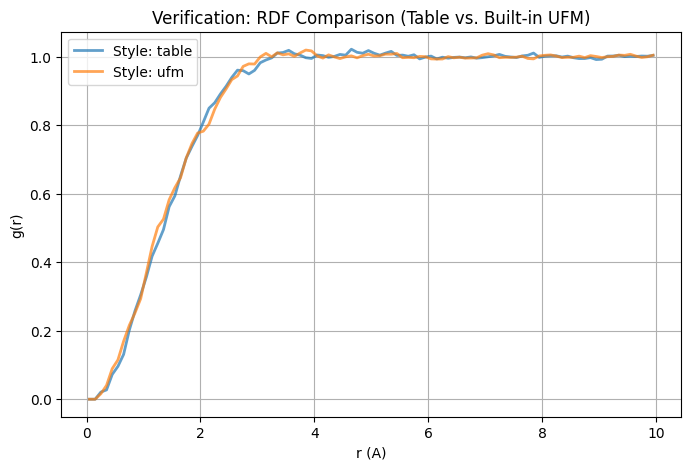


Thermodynamic Comparison (p=1):
Mode: table | rho: 0.045974 | Z:   0.0286 | U_ex [eV/at]:    21.587596
Mode: ufm   | rho: 0.045974 | Z:   0.0288 | U_ex [eV/at]:    21.556865


In [7]:
print("Running Verification: Table vs. UFM Built-in...")
p_ver = 1
T_ver = 1000.0
sigma_ver = 2.5
b2_ver = calculate_b2(p_ver, sigma_ver)
rho_ver = 2.0 / b2_ver
side_ver = (1000 / rho_ver)**(1/3.0)
table_file_ver = generate_uf_table(p_ver, sigma_ver)

styles = ["table", "ufm"]
for style in styles:
    pair_cmd = f"pair_style table linear 5000\npair_coeff 1 1 {table_file_ver} UF_P1" if style == "table" else f"pair_style ufm 10.0\npair_coeff 1 1 {KB_EV*T_ver} {sigma_ver} 10.0"

    in_ver = f"""
units metal
atom_style atomic
boundary p p p
region box block 0 {side_ver} 0 {side_ver} 0 {side_ver}
create_box 1 box
create_atoms 1 random 1000 12345 box
mass 1 28.0855
{pair_cmd}
velocity all create {T_ver} 12345
fix 1 all nvt temp {T_ver} {T_ver} 0.1
thermo 2000
thermo_style custom step press pe
run 5000
reset_timestep 0

# Define variables for thermodynamic properties
variable v_pe equal pe
variable v_press equal press
fix f_ave all ave/time 1 1000 1000 v_v_pe v_v_press

compute myRDF all rdf 100
fix f_rdf all ave/time 1 1000 1000 c_myRDF[*] file rdf_ver_{style}.out mode vector
run 1000
"""
    with open(f"in.ver_{style}", "w") as f: f.write(in_ver)
    !{lmp_cmd} -in in.ver_{style} -log log.ver_{style} > /dev/null

plt.figure(figsize=(8, 5))
for style in styles:
    rdf_ver_file = f"rdf_ver_{style}.out"
    if os.path.exists(rdf_ver_file):
        data = np.loadtxt(rdf_ver_file, skiprows=4)
        plt.plot(data[:,1], data[:,2], label=f"Style: {style}", alpha=0.7, lw=2)

plt.xlabel("r (A)")
plt.ylabel("g(r)")
plt.title("Verification: RDF Comparison (Table vs. Built-in UFM)")
plt.legend()
plt.grid(True)
plt.show()

print("\nThermodynamic Comparison (p=1):")
for style in styles:
    log_ver_path = f"log.ver_{style}"
    if os.path.exists(log_ver_path):
        log_v = open(log_ver_path).read()
        token = re.findall(r"1000\s+[\s\d\.\-]+\s+([\d\.\-]+)\s+([\d\.\-]+)", log_v)
        if token:
            P_avg, PE_avg = float(token[-1][1]), float(token[-1][0])/1000.0
            z = P_avg / (rho_ver * KB_EV * T_ver * EV_A3_TO_BAR)
            print(f"Mode: {style:5} | rho: {rho_ver:8.6f} | Z: {z:8.4f} | U_ex [eV/at]: {PE_avg:12.6f}")
